In [2]:
# Bibliotecas

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, f1_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold

semidirect = 0; direct = 1; indirect = 2
Target = sample age

In [146]:
df = pd.read_csv('Complete_UPV_Database_raw.csv')
df

,Literature,Specimen ID,Country,Specimen Type,Specimen Age (days),Rebar Present,UPV Device Brand & Model,Transducer Diameter (mm),Transducer Frequency (kHz),Standard,...,Width/Diameter (mm),Max Aggregate Size (mm),W/C Ratio,Strength Class,"Design Strength, fck (MPa)","fc,core (MPa)","fc,ref (MPa)","fc,cyl (MPa)",Notes,Unnamed: 24
0,Cianfrone & Facaoaru (1979),C1_25a,Italy,Cube - Laboratory,1.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,16.08,16.08,13.35,NaN,NaN
1,Cianfrone & Facaoaru (1979),C2_25b,Italy,Cube - Laboratory,2.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,27.95,27.95,23.20,NaN,NaN
2,Cianfrone & Facaoaru (1979),C3_25c,Italy,Cube - Laboratory,7.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,38.64,38.64,32.07,NaN,NaN
3,Cianfrone & Facaoaru (1979),C4_25d,Italy,Cube - Laboratory,28.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,47.86,47.86,39.72,NaN,NaN
4,Cianfrone & Facaoaru (1979),C5_123,Italy,Cube - Laboratory,28.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,56.19,56.19,46.64,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4886,Matthews et al. (2025),F11_41,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,94.0,14.0,NaN,B52.5,45.0,86.00,75.05,63.95,NaN,NaN
4887,Matthews et al. (2025),F11_42,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,94.0,13.0,NaN,B52.5,45.0,76.30,66.59,55.49,NaN,NaN
4888,Matthews et al. (2025),F10_43,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,92.0,10.0,NaN,B52.5,45.0,80.10,69.91,58.81,NaN,NaN
4889,Matthews et al. (2025),F10_44,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,95.0,11.0,NaN,B52.5,45.0,86.30,75.32,64.22,NaN,NaN


In [147]:
cols_to_drop = [
    'Literature', 'Specimen ID', 'UPV Device Brand & Model', 'Country', 
    'Standard', 'Strength Class', 'W/C Ratio', 'Design Strength, fck (MPa)', 
    'Notes', 'Unnamed: 24', 'fc,core (MPa)', 'fc,ref (MPa)', 
    'Transducer Diameter (mm)', 'Specimen Type'
]

cols_to_dropna = [
    'Specimen Age (days)', 'Transducer Frequency (kHz)', 
    'Max Aggregate Size (mm)', 'Height (mm)', 'Width/Diameter (mm)', 
    'Rebar Present'
]

df_cleaned = df.drop(columns=cols_to_drop)
df_cleaned = df_cleaned.dropna(subset=cols_to_dropna)

mask_no_rebar = df_cleaned['Rebar Present'].astype(str).str.lower() != 'true'
df_cleaned = df_cleaned[mask_no_rebar]

df_cleaned = df_cleaned.drop(columns=['Rebar Present']).reset_index(drop=True)
df_cleaned

,Specimen Age (days),Transducer Frequency (kHz),Test Type,No. Tests,"Average Velocity, Vp (m/s)",Compression Specimen,Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),"fc,cyl (MPa)"
0,1.0,50.0,Direct,3.0,4440,Cube,150.0,150.0,30.0,13.35
1,2.0,50.0,Direct,3.0,4820,Cube,150.0,150.0,30.0,23.20
2,7.0,50.0,Direct,3.0,5130,Cube,150.0,150.0,30.0,32.07
3,28.0,50.0,Direct,3.0,5230,Cube,150.0,150.0,30.0,39.72
4,28.0,50.0,Direct,3.0,5050,Cube,150.0,150.0,30.0,46.64
...,...,...,...,...,...,...,...,...,...,...
1001,13880.0,54.0,Direct,1.0,4990,Core,94.0,94.0,14.0,63.95
1002,13880.0,54.0,Direct,1.0,4960,Core,94.0,94.0,13.0,55.49
1003,13880.0,54.0,Direct,1.0,5090,Core,94.0,92.0,10.0,58.81
1004,13880.0,54.0,Direct,1.0,4990,Core,93.0,95.0,11.0,64.22


In [148]:
limits = [0, 10, 20, 30, 40, 50, 90, np.inf]
intervals = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-90', '90+']

df_cleaned["Test Type"] = df_cleaned["Test Type"].replace({"Direct": 0, "Indirect": 1, "Semi-direct": 2})
df_cleaned['Strength_range'] = pd.cut(df_cleaned['fc,cyl (MPa)'], bins=limits, labels=intervals, right=False)
df_labeled = df_cleaned.drop(columns=['fc,cyl (MPa)'])
print(df_labeled['Test Type'].unique())
df_labeled

[0 2 1]


C:\Users\juliafmoura\AppData\Local\Temp\ipykernel_9400\2581351142.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned["Test Type"] = df_cleaned["Test Type"].replace({"Direct": 0, "Indirect": 1, "Semi-direct": 2})


,Specimen Age (days),Transducer Frequency (kHz),Test Type,No. Tests,"Average Velocity, Vp (m/s)",Compression Specimen,Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),Strength_range
0,1.0,50.0,0,3.0,4440,Cube,150.0,150.0,30.0,10-20
1,2.0,50.0,0,3.0,4820,Cube,150.0,150.0,30.0,20-30
2,7.0,50.0,0,3.0,5130,Cube,150.0,150.0,30.0,30-40
3,28.0,50.0,0,3.0,5230,Cube,150.0,150.0,30.0,30-40
4,28.0,50.0,0,3.0,5050,Cube,150.0,150.0,30.0,40-50
...,...,...,...,...,...,...,...,...,...,...
1001,13880.0,54.0,0,1.0,4990,Core,94.0,94.0,14.0,50-90
1002,13880.0,54.0,0,1.0,4960,Core,94.0,94.0,13.0,50-90
1003,13880.0,54.0,0,1.0,5090,Core,94.0,92.0,10.0,50-90
1004,13880.0,54.0,0,1.0,4990,Core,93.0,95.0,11.0,50-90


In [ ]:
# categorical = pd.get_dummies(df['Configuration'], prefix='Configuration')
# df = df.drop(columns='Configuration')
# df = pd.concat((df, categorical), axis=1)
# df

<Axes: >

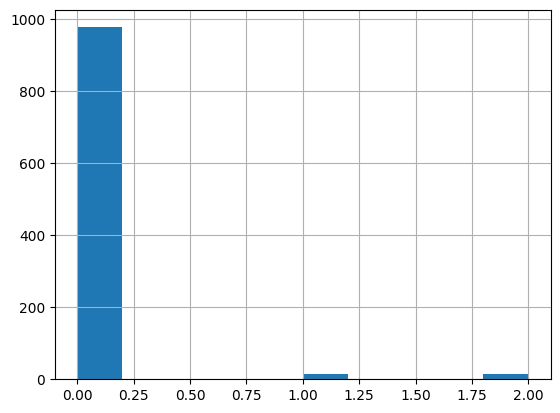

In [149]:
df_labeled['Test Type'].hist()

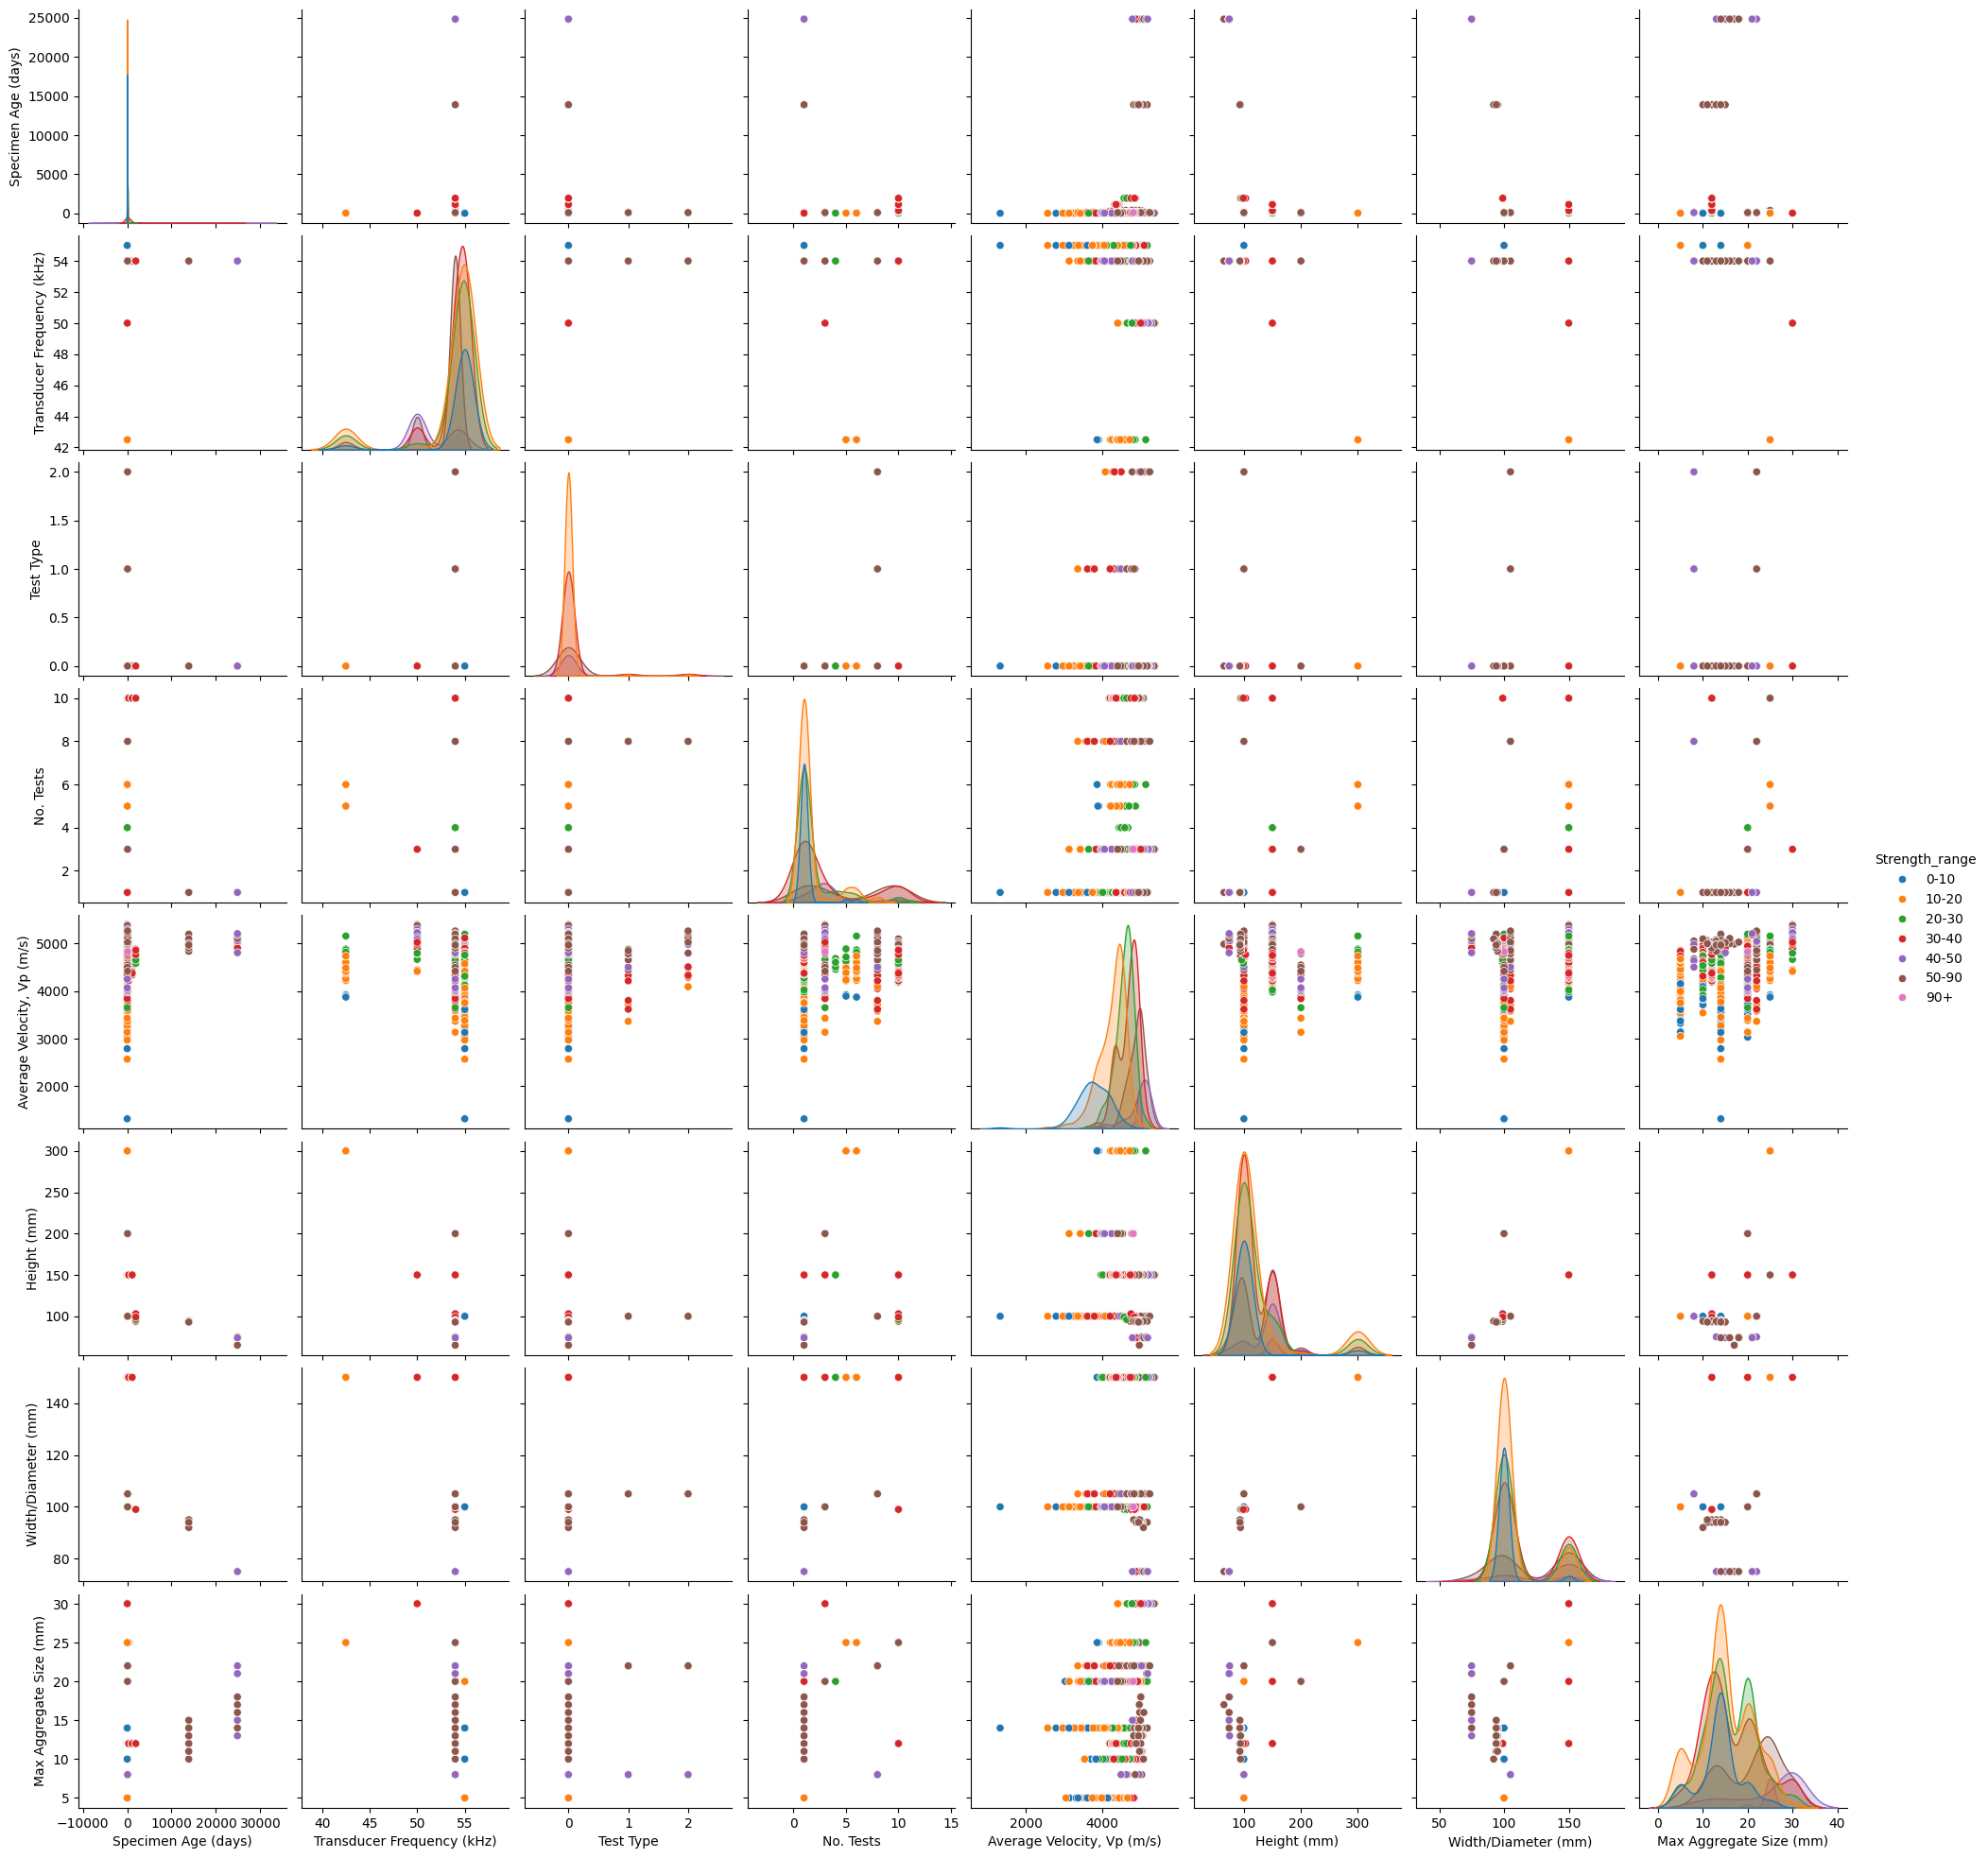

In [150]:
sns.pairplot(df_labeled, hue='Strength_range')
plt.show()

In [144]:
#df = df.dropna(subset=['Target'])
df_train, df_test = train_test_split(df_labeled, test_size=0.3, random_state=42)

In [145]:
df_train

,Specimen Type,Specimen Age (days),Transducer Frequency (kHz),Test Type,No. Tests,"Average Velocity, Vp (m/s)",Compression Specimen,Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),Strength_range
543,Element - Laboratory,28.0,55.0,0,1.0,4640,Cube,100.0,100.0,10.0,10-20
442,Element - Laboratory,60.0,55.0,0,1.0,4520,Cube,100.0,100.0,14.0,10-20
915,Cube - Laboratory,280.0,54.0,0,10.0,4292,Cube,150.0,150.0,12.0,30-40
398,Element - Laboratory,21.0,55.0,0,1.0,4670,Cube,100.0,100.0,14.0,20-30
960,Cylinder - Laboratory,91.0,54.0,0,3.0,4412,Cylinder,200.0,100.0,20.0,50-90
...,...,...,...,...,...,...,...,...,...,...,...
106,Element - Laboratory,28.0,54.0,0,10.0,4590,Cube,150.0,150.0,25.0,50-90
270,Element - Laboratory,21.0,55.0,0,1.0,4870,Cube,100.0,100.0,14.0,20-30
860,Element - Laboratory,90.0,54.0,1,8.0,4759,Cylinder,100.0,105.0,22.0,50-90
435,Element - Laboratory,28.0,55.0,0,1.0,4360,Cube,100.0,100.0,14.0,10-20


In [9]:
target = 'Target'
attributes = list(df.columns[(df.columns != target)])

In [10]:
#Padronizando dados:

min_max_scaler = preprocessing.MinMaxScaler()
min_max_scaler.fit(df_train[attributes])

# transformar os dados para a nova escala (treino e teste)
df_train_norm = min_max_scaler.transform(df_train[attributes])
df_test_norm = min_max_scaler.transform(df_test[attributes])

In [11]:
models_k = {}
 
for k in [1, 3, 5]:
    # preparando o knn com voto ponderado
    knn_norm = KNeighborsClassifier(n_neighbors=k,weights='distance',metric='euclidean')

    # conjunto de treino
    X_train = df_train_norm
    y_train = df_train[[target]]
    knn_norm.fit(X_train, y_train)

    # conjunto de teste
    X_test = df_test_norm
    y_test = df_test[[target]]

    y_pred = knn_norm.predict(X_test)

    # comparando desempenho

    acc = knn_norm.score(X_test, y_test)
    models_k[k] = {"modelo": knn_norm, "acuracia": acc}
    print(f"\n── k = {k}  |  Acurácia: {acc:.2%} ──")
    print(classification_report(y_test, y_pred))


── k = 1  |  Acurácia: 29.41% ──
              precision    recall  f1-score   support

           1       0.70      0.51      0.59        45
           3       0.23      0.25      0.24        28
           7       0.09      0.13      0.11        30
          14       0.20      0.24      0.22        29
          28       0.31      0.24      0.27        38

    accuracy                           0.29       170
   macro avg       0.31      0.27      0.29       170
weighted avg       0.34      0.29      0.31       170


── k = 3  |  Acurácia: 27.06% ──
              precision    recall  f1-score   support

           1       0.70      0.51      0.59        45
           3       0.15      0.14      0.15        28
           7       0.12      0.20      0.15        30
          14       0.17      0.17      0.17        29
          28       0.26      0.21      0.23        38

    accuracy                           0.27       170
   macro avg       0.28      0.25      0.26       170
weighted 

C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expecte

In [12]:
# Classificador nulo que apenas chuta uma resposta considerando a distribuições das classes
dummy_clf = DummyClassifier(strategy='stratified')
dummy_clf.fit(X_train,y_train)
print(classification_report(y_test, dummy_clf.predict(X_test)))

              precision    recall  f1-score   support

           1       0.21      0.09      0.12        45
           3       0.27      0.39      0.32        28
           7       0.19      0.20      0.19        30
          14       0.12      0.14      0.13        29
          28       0.23      0.26      0.24        38

    accuracy                           0.21       170
   macro avg       0.20      0.22      0.20       170
weighted avg       0.20      0.21      0.20       170



In [13]:
# Validação cruzada estratificada
X = df.drop(columns=['Target']).values
y = df['Target'].values
scaler = StandardScaler()
skf = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

print(X)
for k in [1, 3, 5]:
    fold_accuracies = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        clf = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
        clf.fit(X_train_sc, y_train)

        predictions   = clf.predict(X_test_sc)
        accuracy      = accuracy_score(y_test, predictions)
        fold_accuracies.append(accuracy)

        print(f"  Fold {fold:02d}" f"| Acurácia: {accuracy:.4f}")

    print(f"  Acurácia média (k={k}): {np.mean(fold_accuracies):.4f} \n")

[[0.533 109.3 4880.15 ... True False False]
 [0.445 91.1 4879.25 ... True False False]
 [0.342 68.6 4980.03 ... True False False]
 ...
 [0.229 46.9 4874.2 ... False False True]
 [0.305 62.2 4900.32 ... False False True]
 [0.381 88.2 4319.73 ... False False True]]
  Fold 01| Acurácia: 0.2281
  Fold 02| Acurácia: 0.2982
  Fold 03| Acurácia: 0.3684
  Fold 04| Acurácia: 0.3509
  Fold 05| Acurácia: 0.3158
  Fold 06| Acurácia: 0.3929
  Fold 07| Acurácia: 0.2679
  Fold 08| Acurácia: 0.2321
  Fold 09| Acurácia: 0.2679
  Fold 10| Acurácia: 0.3036
  Acurácia média (k=1): 0.3026 

  Fold 01| Acurácia: 0.2456
  Fold 02| Acurácia: 0.2982
  Fold 03| Acurácia: 0.3509
  Fold 04| Acurácia: 0.3860
  Fold 05| Acurácia: 0.3333
  Fold 06| Acurácia: 0.3393
  Fold 07| Acurácia: 0.2857
  Fold 08| Acurácia: 0.2321
  Fold 09| Acurácia: 0.3214
  Fold 10| Acurácia: 0.3393
  Acurácia média (k=3): 0.3132 

  Fold 01| Acurácia: 0.2982
  Fold 02| Acurácia: 0.3158
  Fold 03| Acurácia: 0.3333
  Fold 04| Acurácia: 0.386